In [1]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
import pandas as pd
from IPython.display import display, Markdown

import os               # 파일 및 디렉토리 경로를 처리하는 파이썬 내장 모듈
import joblib           # 학습된 모델을 파일로 저장하고 복원하는 직렬화 모듈
import numpy as np      # 수치계산을 위한 파이썬 내장 모듈
import glob as gl       # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈
import datetime as dt   # 날짜 및 시간 처리를 위한 파이썬 내장 모듈

# 훈련, 검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 성능평가 지표 계산 함수
from sklearn.metrics import (
    r2_score,                           # 결정계수 (R2)
    mean_absolute_error,                # 평균절대오차 (MAE)
    mean_squared_error,                 # 평균제곱오차 (MSE)
    mean_squared_log_error,             # 평균제곱로그오차 (MSLE)
    mean_absolute_percentage_error      # 평균절대백분율오차 (MAPE)
)

# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.29

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.29, 최신 버전: 0.5.34)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



In [2]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("local_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["spatial_cluster", "년도", "기준월"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   총_가맹점수           6240 non-null   float64 
 1   소매_비율            6240 non-null   float64 
 2   기타_비율            6240 non-null   float64 
 3   총인구수             6240 non-null   float64 
 4   월유동인구수           6240 non-null   float64 
 5   spatial_cluster  6240 non-null   category
 6   기준월              6240 non-null   category
 7   년도               6240 non-null   category
 8   people_cluster   6240 non-null   int64   
 9   분기               6240 non-null   int64   
 10  매출금액             6240 non-null   float64 
dtypes: category(3), float64(6), int64(2)
memory usage: 408.6 KB


## 4. 데이터에서 독립변수와 종속변수 분리
### 머신러닝에서는 독립변수를 feature, 종속변수를 target으로 명명한다.

In [3]:
feature = df.drop(columns=["매출금액"])
target = df["매출금액"]
feature.shape, target.shape

((6240, 10), (6240,))

## 5. 훈련, 검증 데이터 분리

In [4]:
# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 10), (1248, 10), (4992,), (1248,))

## 6. 학습을 완료한 모델이 저장될 폴더

In [5]:
project_name = "local"
base_dir = f"{project_name}/baseline"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)

작업 폴더: local\baseline
학습 완료 [ 1/11] : linear
학습 완료 [ 2/11] : ridge
학습 완료 [ 3/11] : lasso
학습 완료 [ 4/11] : elasticnet
학습 완료 [ 5/11] : kneighbors
학습 완료 [ 6/11] : svr
학습 완료 [ 7/11] : decisiontree
학습 완료 [ 8/11] : randomforest
학습 완료 [ 9/11] : xgb
학습 완료 [10/11] : lgbm
학습 완료 [11/11] : catboost


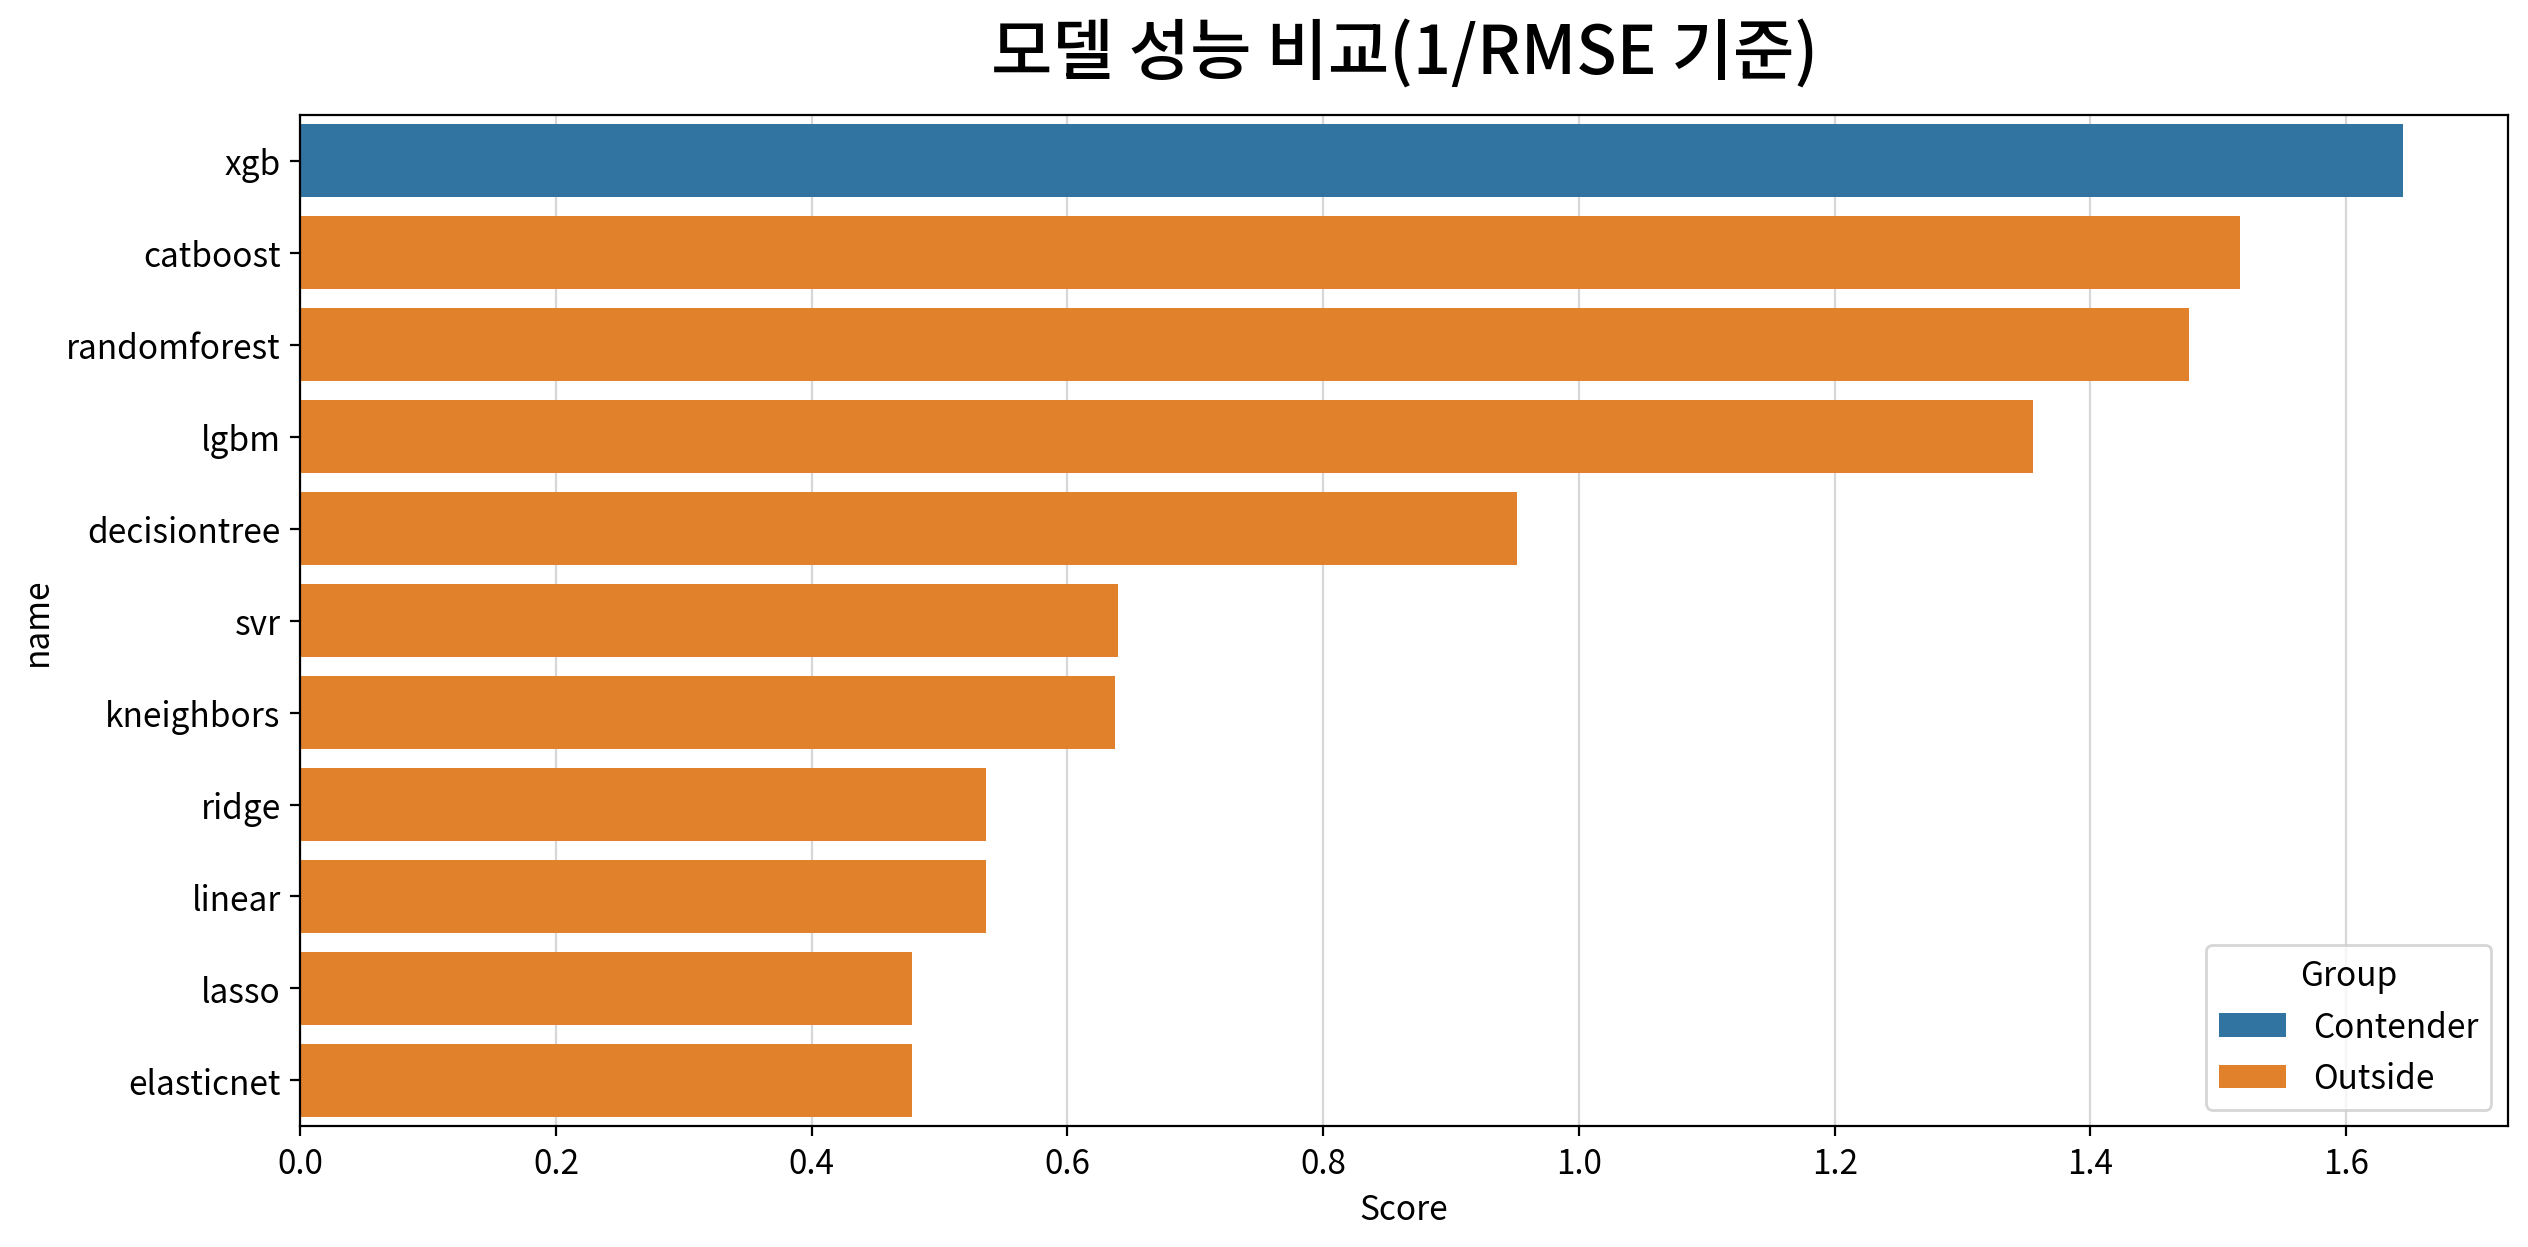


모델 11개 학습·저장 완료 → local\baseline


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
xgb,1,Contender,XGBRegressor,0.915,0.420,0.370,0.608,0.043,0.031,-0.004,0.000,1.644
catboost,2,Outside,CatBoostRegressor,0.901,0.474,0.434,0.659,0.046,0.035,-0.005,0.084,1.517
randomforest,3,Outside,RandomForestRegressor,0.895,0.434,0.459,0.677,0.047,0.032,-0.006,0.113,1.477
lgbm,4,Outside,LGBMRegressor,0.875,0.523,0.545,0.738,0.052,0.039,-0.007,0.214,1.355
decisiontree,5,Outside,DecisionTreeRegressor,0.747,0.586,1.105,1.051,0.071,0.044,-0.004,0.728,0.951
svr,6,Outside,SVR,0.441,0.967,2.444,1.563,0.102,0.069,-0.002,1.571,0.640
kneighbors,7,Outside,KNeighborsRegressor,0.437,1.079,2.460,1.569,0.104,0.079,-0.018,1.579,0.638
ridge,8,Outside,Ridge,0.205,1.302,3.476,1.864,0.123,0.094,-0.018,2.066,0.536
linear,9,Outside,LinearRegression,0.205,1.302,3.476,1.864,0.123,0.094,-0.018,2.066,0.536


CPU times: total: 1min 52s
Wall time: 42.1 s


In [6]:
%%time
my_ml.reg_baseline("local", x_train, y_train, x_test, y_test)

## 튜닝 저장폴더 구성

In [7]:
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [8]:
# 튜닝하기 원하는 모델을 로드하여 딕셔너리 형태로 저장
models = {
    "linear": my_ml.load_model(f"{base_dir}/linear.pkl"),
    "ridge": my_ml.load_model(f"{base_dir}/ridge.pkl"),
    "lasso": my_ml.load_model(f"{base_dir}/lasso.pkl"),
    "elasticnet": my_ml.load_model(f"{base_dir}/elasticnet.pkl"),
    "kneighbors": my_ml.load_model(f"{base_dir}/kneighbors.pkl"),
    "svr": my_ml.load_model(f"{base_dir}/svr.pkl"),
    "decisiontree": my_ml.load_model(f"{base_dir}/decisiontree.pkl"),
    "randomforest": my_ml.load_model(f"{base_dir}/randomforest.pkl"),
    "xgb": my_ml.load_model(f"{base_dir}/xgb.pkl"),
    "lgbm": my_ml.load_model(f"{base_dir}/lgbm.pkl"),
    "catboost": my_ml.load_model(f"{base_dir}/catboost.pkl")
}

작업 폴더: local\tuned
탐색 범위: 실습용(축소)
탐색 완료 [ 1/11] : linear (0.3초, CV RMSE=1.7931)
    최적 조합: {'model__fit_intercept': True, 'model__positive': False}
탐색 완료 [ 2/11] : ridge (0.5초, CV RMSE=1.7930)
    최적 조합: {'model__alpha': 10.0, 'model__solver': 'auto'}
탐색 완료 [ 3/11] : lasso (0.5초, CV RMSE=1.7929)
    최적 조합: {'model__alpha': 0.001, 'model__max_iter': 1000}
탐색 완료 [ 4/11] : elasticnet (0.6초, CV RMSE=1.7929)
    최적 조합: {'model__alpha': 0.001, 'model__l1_ratio': 0.8}
탐색 완료 [ 5/11] : kneighbors (0.7초, CV RMSE=1.4945)
    최적 조합: {'model__n_neighbors': 10, 'model__weights': 'uniform'}
탐색 완료 [ 6/11] : svr (5.0초, CV RMSE=1.5510)
    최적 조합: {'model__C': 1.0, 'model__epsilon': 0.2, 'model__gamma': 0.1}
탐색 완료 [ 7/11] : decisiontree (0.7초, CV RMSE=1.0191)
    최적 조합: {'model__max_depth': None, 'model__min_samples_leaf': 1}
탐색 완료 [ 8/11] : randomforest (9.0초, CV RMSE=0.6498)
    최적 조합: {'model__min_samples_leaf': 1, 'model__n_estimators': 300}
탐색 완료 [ 9/11] : xgb (6.3초, CV RMSE=0.5977)
    최적 조합: {'mod

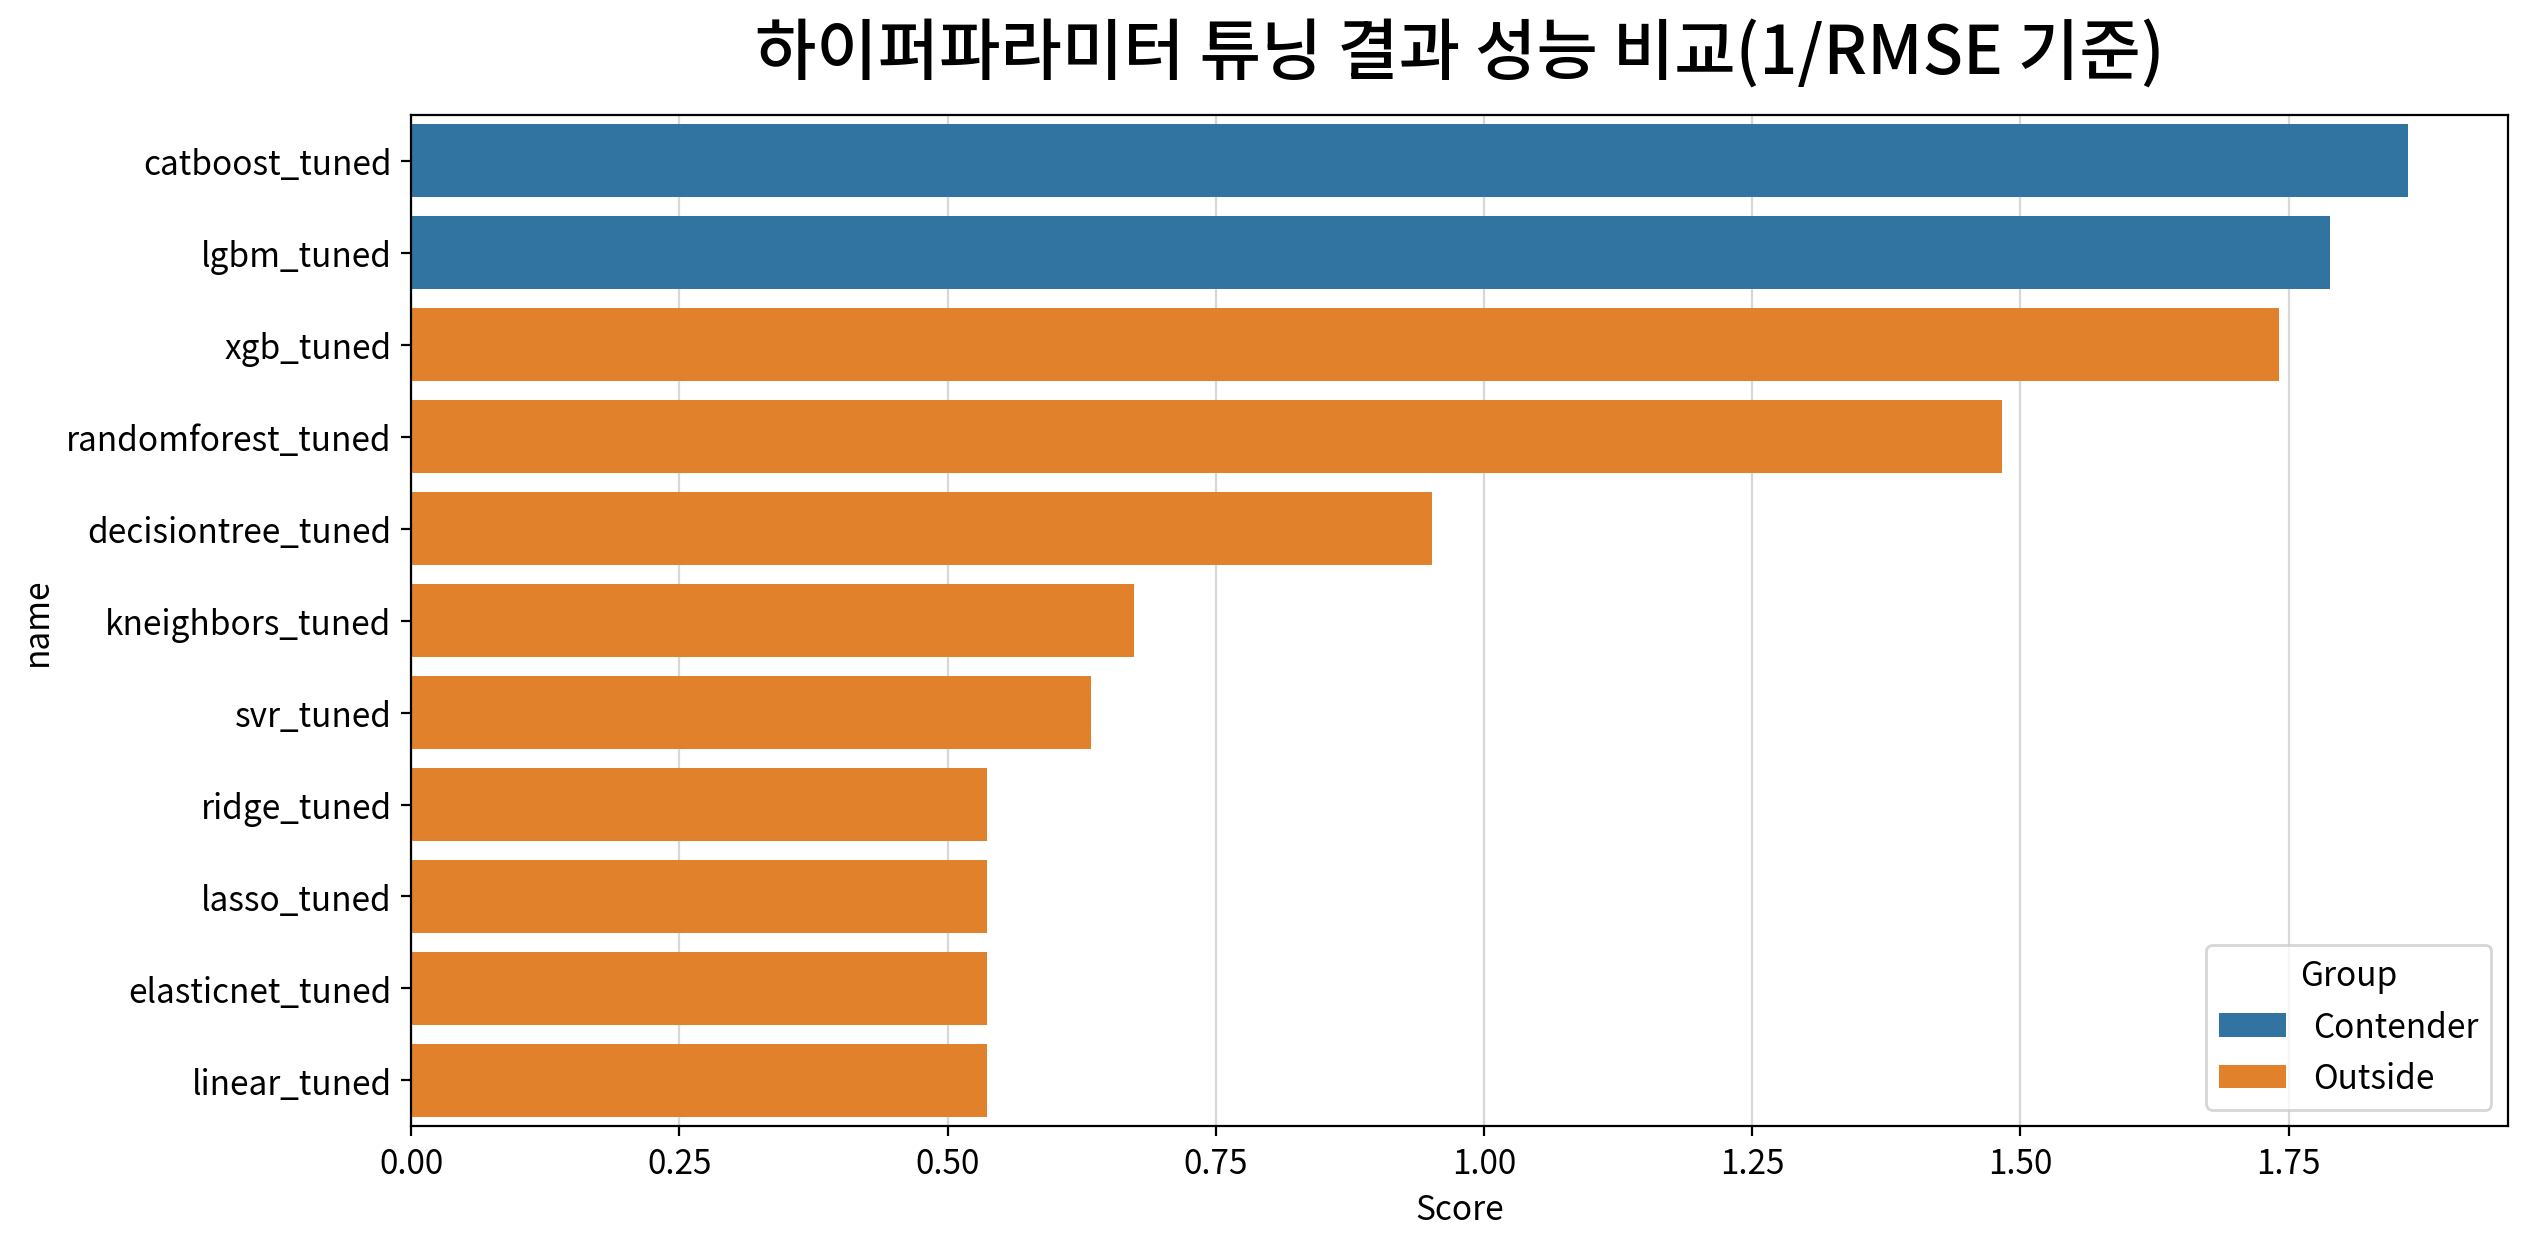


모델 11개 튜닝·저장 완료 → local\tuned


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost_tuned,1,Contender,CatBoostRegressor,0.934,0.379,0.289,0.537,0.038,0.028,-0.003,0.000,1.862
lgbm_tuned,2,Contender,LGBMRegressor,0.929,0.387,0.312,0.559,0.040,0.029,-0.004,0.041,1.789
xgb_tuned,3,Outside,XGBRegressor,0.925,0.390,0.330,0.574,0.041,0.029,-0.004,0.069,1.741
randomforest_tuned,4,Outside,RandomForestRegressor,0.896,0.433,0.455,0.675,0.047,0.032,-0.005,0.256,1.483
decisiontree_tuned,5,Outside,DecisionTreeRegressor,0.747,0.586,1.105,1.051,0.071,0.044,-0.004,0.956,0.951
kneighbors_tuned,6,Outside,KNeighborsRegressor,0.497,1.001,2.200,1.483,0.099,0.073,-0.018,1.761,0.674
svr_tuned,7,Outside,SVR,0.431,0.983,2.487,1.577,0.103,0.070,-0.003,1.936,0.634
ridge_tuned,8,Outside,Ridge,0.205,1.302,3.475,1.864,0.123,0.094,-0.018,2.470,0.536
lasso_tuned,9,Outside,Lasso,0.205,1.302,3.475,1.864,0.123,0.094,-0.018,2.470,0.536


CPU times: total: 3min 21s
Wall time: 6min 28s


In [9]:
%%time
my_ml.reg_tunes("local", models, x_train, y_train, x_test, y_test, practice=True)

# 5부. 모델을 검증하고 해석하는 단계
### 미션 10. "점수가 배운 것인지 외운 것인지 가른다"

In [10]:
# 독립변수 분리
feature = df.drop(columns=["매출금액"])

# 종속변수 분리
target = df["매출금액"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 10), (1248, 10), (4992,), (1248,))

In [11]:
# 튜닝이 완료된 모델이 저장되어 있는 폴더 위치 지정
project_name = "local"
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [12]:
models = {
    "catboost": my_ml.load_model(f"{tuned_dir}/catboost_tuned.pkl"),
    "lgbm": my_ml.load_model(f"{tuned_dir}/lgbm_tuned.pkl")
}

In [13]:
%%time

for model_name, model in models.items():
    display(Markdown(f"#### ▶︎ {model_name}"))
    my_diag.overfit(model, x_train, y_train, x_test, y_test)

#### ▶︎ catboost

CPU times: total: 922 ms
Wall time: 51.2 s


KeyboardInterrupt: 